## Data Parsing 
1. It is Important Step in RAG.
2. Data parsing is extraction useful information, structured data from raw files.
3. Modality: Image,Text,Audio,Video.
4. Data Can be Any Format: pdf,xml,html,mp4,json,yaml,docx,csv,xls.
5. Structured Data: Data Tables(SQL),csv, excel sheet.
6. Semi Structured Data: json,xml,html,yaml.
7. Unstructred Data: PDF,Reports,images,Audio,Video,email.

In [2]:
import json
from pathlib import Path  #Here this read file paths supports both  / and \
from docling.datamodel.base_models import InputFormat  #InputFormat is an Enum class that defines the supported input formats(pdf,Docx,html etc) for the data model

In [3]:
InputFormat.PDF

<InputFormat.PDF: 'pdf'>

In [9]:

from docling.datamodel.pipeline_options import(PdfPipelineOptions,TableStructureOptions,TesseractCliOcrOptions) 

## PipelineOptions
1. It is master Configuration Object that control the entire processing Pipeline.
2. WithOut Anything Docling choose its default Behavior
           Pipeline
              ||
        Default Settings
3. With custome Options one can specify what is required.

          Pipeline 
          ||
           ✓ Enable OCR
           ✓ Detect tables
           ✓ Choose OCR engine
           ✓ Configure OCR languages
           ✓ Preserve table structure
## TesseractCliOcrOptions
1. Docling Support OCR engine and Tesseract is Commonly used OCR Engine.
2. TesseractCliOcrOptions allows you to configure how Tesseract performs OCR.
3. OCR Recognize Text inside Imgae.
## TableStructureOptions
1. TableStructureOptions recognizes and preserves Table structure (Rows And Columns)

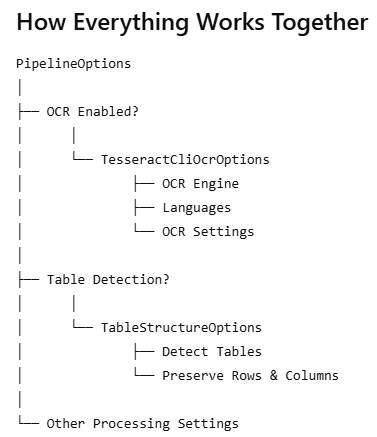

In [39]:
#Main Docling Parser Converter
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)

In [40]:
from docling_core.types.doc import (
    ImageRefMode,
    PictureItem,
    TableItem,
)

In [ ]:
PDF_PATH = Path(
    r"C:\Mine\AI\Full Stack Gen AI  BootCamp (KrishNaik)\Practicals"
        r"\Class-32-18-July-2026_DataParsing_Extended\data\complex_rag_parsing_sample_image.pdf"
)

OUTPUT_DIR = Path(
   r"C:\Mine\AI\Full Stack Gen AI  BootCamp (KrishNaik)\Practicals"
   r"\Class-32-18-July-2026_DataParsing_Extended\data"
)

PAGE_IMAGE_DIR = OUTPUT_DIR / "page_images"
PICTURE_DIR = OUTPUT_DIR / "extracted_pictures"
TABLE_DIR = OUTPUT_DIR / "extracted_tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PAGE_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PICTURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if not PDF_PATH.exists():
    raise FileNotFoundError(f"PDF not found: {PDF_PATH}")

In [44]:
pipeline_options = PdfPipelineOptions()

In [45]:
# Enable OCR
pipeline_options.do_ocr = True

In [59]:
pipeline_options.ocr_options = TesseractCliOcrOptions(
    tesseract_cmd=r"C:\Program Files\Tesseract-OCR\tesseract.exe",
    lang=["eng"],

    # False = selectable text + OCR where required
    # True = OCR complete pages
    force_full_page_ocr=True,
)

In [60]:
# Enable table structure extraction
pipeline_options.do_table_structure = True

In [48]:
pipeline_options.table_structure_options = TableStructureOptions(
    do_cell_matching=True,
)

In [49]:
# Preserve page and picture images
pipeline_options.images_scale = 2.0
pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True

In [61]:
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

In [62]:
print("Parsing PDF with Docling...")

conversion_result = converter.convert(PDF_PATH)

Parsing PDF with Docling...
